# Kurtosis and vorticity intensity across resolutions

The calculation below do not take into account the difference between formed and non-formed eddies

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client
from scipy import ndimage
from skimage import measure
import pandas as pd
import plotly.express as px
import warnings

In [2]:
client = Client(threads_per_worker = 1,memory_limit='2900gb')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41857 instead
  warnings.warn(
2025-10-24 15:08:57,647 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.44 TiB
2025-10-24 15:08:57,654 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.44 TiB
2025-10-24 15:08:57,661 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.44 TiB
2025-10-24 15:08:57,668 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.44 TiB
2025-10-24 15:08:57,677 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.44 TiB
2025-10-24 15:08:57,684 - distributed.nan

In [3]:
# Base vorticity variables directory
base_vortdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'

In [4]:
start_date='2000-01-01'
end_date = '2001-01-01'

In [5]:
%%time
#importing vorticity 
# # # Panan0025
ζ_0025 = xr.open_mfdataset(base_vortdir + 'panan0025_rerun/EKE_along_contour/vorticity_xyt_*_panan0025.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_005 = xr.open_mfdataset(base_vortdir + 'panan005_rerun/EKE_along_contour/vorticity_xyt_panan005.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()
# # # Panan005
ζ_01 = xr.open_mfdataset(base_vortdir + 'panan01_rerun/EKE_along_contour/vorticity_xyt_panan01.nc')\
    .Surface_Vorticity.sel(time=slice(start_date,end_date)).chunk(chunks={"time":'200gb'}).compute()

CPU times: user 3min 9s, sys: 4min 44s, total: 7min 53s
Wall time: 9min 53s


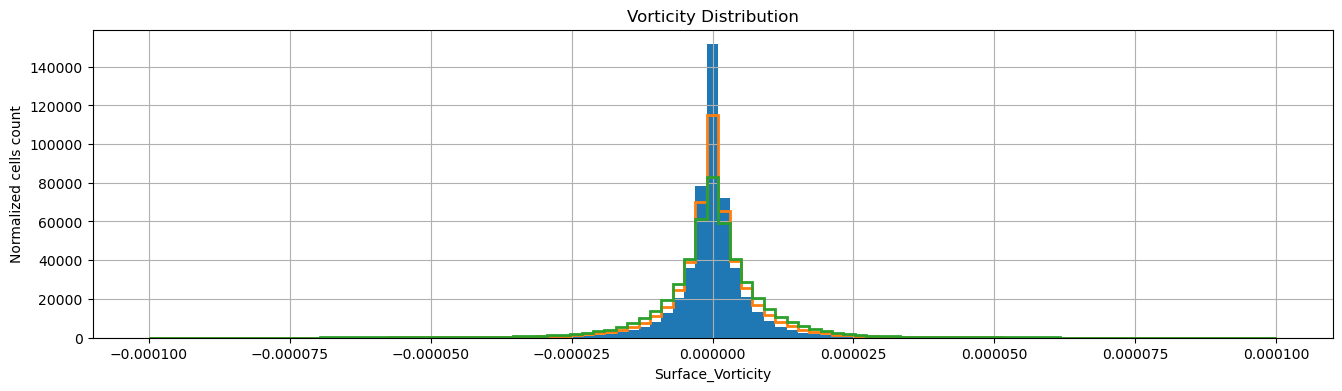

In [6]:
plt.figure(figsize=(16,4))
ζ_bins = np.linspace(-1e-4,1e-4,100)
ζ_01.plot.hist(bins = ζ_bins, density=True)
ζ_005.plot.hist(bins = ζ_bins, histtype='step',edgecolor='tab:orange',density=True,lw=2)
ζ_0025.plot.hist(bins = ζ_bins, histtype='step',edgecolor='tab:green',density=True,lw=2)

plt.ylabel(r'Normalized cells count');
plt.title('Vorticity Distribution')
#plt.yscale('log')
plt.grid()

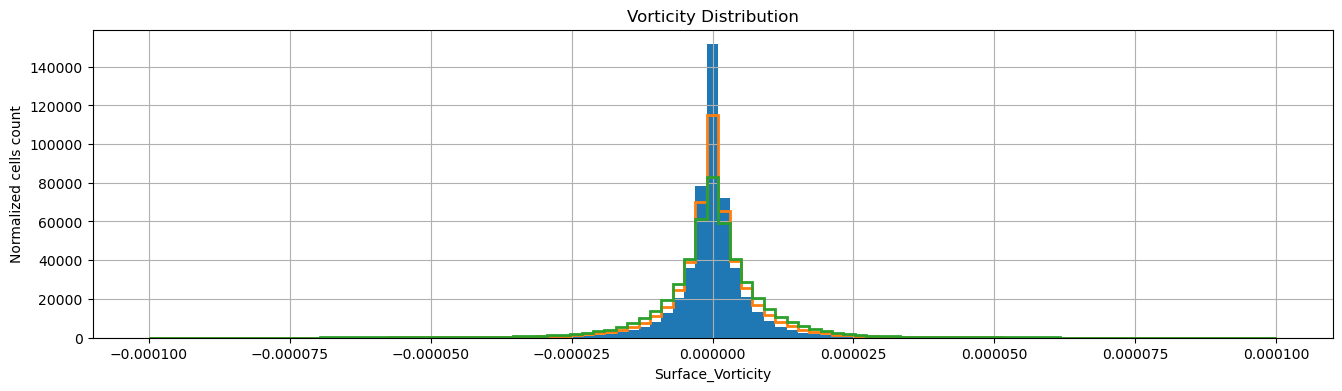

In [7]:
plt.figure(figsize=(16,4))
ζ_bins = np.linspace(-1e-4,1e-4,100)
ζ_01.plot.hist(bins = ζ_bins, density=True)
ζ_005.plot.hist(bins = ζ_bins, histtype='step',edgecolor='tab:orange',density=True,lw=2)
ζ_0025.plot.hist(bins = ζ_bins, histtype='step',edgecolor='tab:green',density=True,lw=2)

plt.ylabel(r'Normalized cells count');
plt.title('Vorticity Distribution')
#plt.yscale('log')
plt.grid()

### Mixed layer changes in vorticity regimes

In [3]:
#in this definition, no frequency can be used only for static data
catalog = intake.cat.access_nri
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0):
    warnings.filterwarnings('ignore')
    if experiment== "panant-01-zstar-ACCESSyr2":
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    else: 
        #other resolutions have the same variable with z_l and z_l_sub z dim in different times.
        # I will filter to the time I want knowing th their specificities
        #IOW this fix works just for the models and variables used in this notebook
        if variable=='uo' or variable=='vo':
            var = catalog[experiment].search(variable=variable, frequency = frequency)
            keysnames = var.keys() ; search_term = "z_l_sub01"
            matches = [s for s in keysnames if search_term in s]
            var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = matches).to_dask(xarray_open_kwargs={'decode_timedelta':True})
        else:
            var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [9]:
%%time
#importing mixed layer depth - notice we have a problem that we dont have MLD daily

MLD_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()
MLD_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()
MLD_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1mon',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()


CPU times: user 21.9 s, sys: 17.4 s, total: 39.3 s
Wall time: 45.3 s


In [10]:
#importing daily for interpolation in time
MLD_01d = importer("panant-01-zstar-ACCESSyr2",catalog,"mlotst",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xh':'15gb','yh':'15gb','time':'15gb'}).compute()

Spatial interpolation into q points

In [11]:
%%time
#interpolating into q points 0.1
MLD_01d_cut = MLD_01d.interp(xh=ζ_01.xq,yh=ζ_01.yq)

CPU times: user 1min 24s, sys: 58.6 s, total: 2min 23s
Wall time: 1min 26s


In [12]:
%%time
#interpolating into q points - 0.05
MLD_005dint_cut=MLD_005.interp(xh = ζ_005.xq, yh = ζ_005.yq)

CPU times: user 7.14 s, sys: 6.18 s, total: 13.3 s
Wall time: 7.91 s


In [13]:
%%time
#interpolating into q points - 0.025
MLD_0025dint_cut=MLD_0025.interp(xh = ζ_0025.xq, yh = ζ_0025.yq)

CPU times: user 31.5 s, sys: 26.4 s, total: 58 s
Wall time: 34.6 s


temporal interpolation into daily

In [14]:
%%time
#interpoalting MLD into daily data - this willlikely take ages
MLD_0025dint = MLD_0025dint_cut.interp(time=MLD_01d.time)
MLD_0025dint = MLD_0025dint.isel(time=slice(1,-1))

CPU times: user 17min 50s, sys: 34min 58s, total: 52min 49s
Wall time: 32min 18s


In [15]:
%%time
MLD_005dint = MLD_005dint_cut.interp(time=MLD_01d.time)

CPU times: user 1min 52s, sys: 2min 34s, total: 4min 27s
Wall time: 2min 43s


cutting out date eto large sea ice season only

In [16]:
MLD_0025dint_winter = MLD_0025dint.sel(time=slice('2000-08-01','2001-10-31'))
MLD_005dint_winter = MLD_005dint.sel(time=slice('2000-08-01','2001-10-31'))

importing areas

In [17]:
#importing grid cell area
areacello_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(ζ_0025.yq.min(),ζ_0025.yq.max())).compute()
areacello_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(ζ_005.yq.min(),ζ_005.yq.max())).compute()
areacello_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"areacello_bu").sel(yq=slice(ζ_01.yq.min(),ζ_01.yq.max())).compute()

In [18]:
%%time
#importing sea ice thickness
SIT_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()



CPU times: user 8min 14s, sys: 5min 44s, total: 13min 59s
Wall time: 15min 11s


In [20]:
#fixing coords
SIT_01_formask = SIT_01.rename({'yT': 'yq', 'xT':'xq'}).sel(yq=slice(ζ_01.yq.min().values,ζ_01.yq.max().values))
SIT_01_formask ['xq'] = ζ_01.xq[1:].values; SIT_01_formask ['yq'] = ζ_01.yq[1:].values

SIT_005_formask = SIT_005.rename({'yT': 'yq', 'xT':'xq'}).sel(yq=slice(ζ_005.yq.min().values,ζ_005.yq.max().values))
SIT_005_formask ['xq'] = ζ_005.xq[1:].values; SIT_005_formask ['yq'] = ζ_005.yq[1:].values


SIT_0025_formask = SIT_0025.rename({'yT': 'yq', 'xT':'xq'}).sel(yq=slice(ζ_0025.yq.min().values,ζ_0025.yq.max().values))
SIT_0025_formask ['xq'] = ζ_0025.xq[1:].values; SIT_0025_formask ['yq'] = ζ_0025.yq[1:].values

Creating SIT mask

In [21]:
SIT_01_mask=1+(SIT_01_formask.where(SIT_01_formask>0)*0)
SIT_005_mask=1+(SIT_005_formask.where(SIT_005_formask>0)*0)
SIT_0025_mask=1+(SIT_0025_formask.where(SIT_0025_formask>0)*0)

SIT mask will be incorporated into the area for averaging

In [22]:
areacello_01_forweight = areacello_01 * SIT_01_mask
areacello_005_forweight = areacello_005 * SIT_005_mask
areacello_0025_forweight = areacello_0025 * SIT_0025_mask

#### Averaging MLD in vorticity states

In [25]:
positive_ζcut=+1e-5
negative_ζcut=-1e-5

In [26]:
# MLD_01d_cut_mean=(MLD_01d_cut *SIT_01_mask).weighted(areacello_01.fillna(0)).mean()
# MLD_005d_cut_mean=(MLD_005dint *SIT_005_mask).weighted(areacello_005.fillna(0)).mean()
# MLD_0025d_cut_mean=(MLD_0025dint *SIT_0025_mask).weighted(areacello_0025.fillna(0)).mean()

In [27]:
# MLD_01d_cut_mean,MLD_005d_cut_mean,MLD_0025d_cut_mean

In [28]:
#anticyclonic means!
MLD01_anticyclonic = MLD_01d_cut.where(ζ_01>=positive_ζcut).weighted(areacello_01_forweight.fillna(0)).mean()
MLD005_anticyclonic = MLD_005dint.where(ζ_005>=positive_ζcut).weighted(areacello_005_forweight.fillna(0)).mean()
MLD0025_anticyclonic = MLD_0025dint.where(ζ_0025>=positive_ζcut).weighted(areacello_0025_forweight.fillna(0)).mean()

In [29]:
#cyclonic means!
MLD01_cyclonic = MLD_01d_cut.where(ζ_01<=negative_ζcut).weighted(areacello_01_forweight.fillna(0)).mean()
MLD005_cyclonic = MLD_005dint.where(ζ_005<=negative_ζcut).weighted(areacello_005_forweight.fillna(0)).mean()
MLD0025_cyclonic = MLD_0025dint.where(ζ_0025<=negative_ζcut).weighted(areacello_0025_forweight.fillna(0)).mean()

In [30]:
MLD01_anticyclonic,MLD01_cyclonic

(<xarray.DataArray 'mlotst' ()> Size: 8B
 array(88.50526095),
 <xarray.DataArray 'mlotst' ()> Size: 8B
 array(83.18712077))

([<matplotlib.axis.XTick at 0x15281819e6d0>,
 [Text(-1, 0, 'Cyclonic ($ - \\zeta$)'),
  Text(1, 0, 'Anticyclonic ($ + \\zeta$)')])

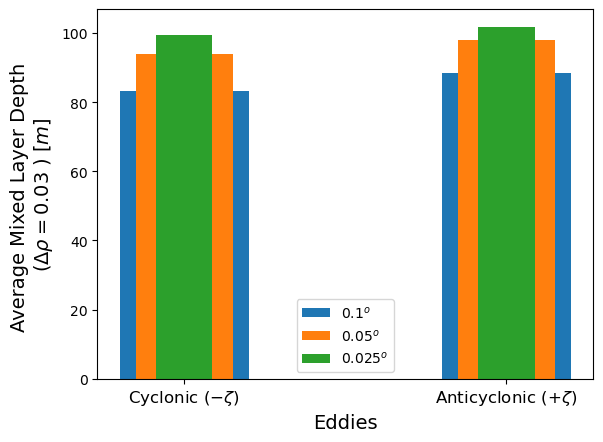

In [31]:
plt.bar([-1,1],[MLD01_cyclonic,MLD01_anticyclonic],label=r'$0.1^o$')
plt.bar([-1,1],[MLD005_cyclonic,MLD005_anticyclonic],width=0.6,label=r'$0.05^o$')
plt.bar([-1,1],[MLD0025_cyclonic,MLD0025_anticyclonic],width=0.35,label=r'$0.025^o$')
plt.legend()
plt.ylabel('Average Mixed Layer Depth \n' + r'($\Delta \rho =0.03$ ) [$m$]',fontsize=14)
plt.xlabel('Eddies',fontsize=14)
plt.xticks(ticks=[-1,1],labels=[r'Cyclonic ($ - \zeta$)',r'Anticyclonic ($ + \zeta$)'],fontsize=12)

In [4]:
variables_01 = catalog["panant-01-zstar-ACCESSyr2"].unique().variable
print(variables_01)

['average_DT', 'average_T1', 'average_T2', 'nv', 'siconc', 'sithick', 'time', 'time_bnds', 'xT', 'xTe', 'yT', 'yTe', 'fsitherm', 'hfds', 'mlotst', 'salt_flux', 'salt_flux_added', 'sob', 'tauuo', 'tauvo', 'tob', 'umo_2d', 'vmo_2d', 'wfo', 'xh', 'xq', 'yh', 'yq', 'zos', 'rho2_i', 'rho2_l', 'umo', 'vmo', 'volcello', 'agessc', 'rhopot0', 'rhopot2', 'so', 'thetao', 'uo', 'vo', 'z_i', 'z_l', 'Coriolis', 'areacello', 'areacello_bu', 'areacello_cu', 'areacello_cv', 'deptho', 'dxCu', 'dxCv', 'dxt', 'dyCu', 'dyCv', 'dyt', 'geolat', 'geolat_c', 'geolat_u', 'geolat_v', 'geolon', 'geolon_c', 'geolon_u', 'geolon_v', 'wet', 'wet_c', 'wet_u', 'wet_v', 'net_melt', 'IX_TRANS', 'IY_TRANS', 'xB', 'yB', 'T_adx_2d', 'T_ady_2d', 'zl', 'z_l_sub01', 'lrunoff', 'precip', 'Kd_interface', 'T_adx', 'T_ady', 'Kd_BBL', 'Kd_ePBL', 'Kd_heat', 'Kd_salt', 'Kd_shear', 'CAu', 'CAv', 'PFu', 'PFv', 'diffu', 'diffv', 'du_dt_visc', 'dudt', 'dv_dt_visc', 'dvdt', 'gKEu', 'gKEv', 'rvxu', 'rvxv', 'u_BT_accel', 'v_BT_accel', 'PRCm

In [10]:
variables_005 = catalog["panant-005-zstar-ACCESSyr2"].unique().variable
print(variables_005)

['average_DT', 'average_T1', 'average_T2', 'net_melt', 'nv', 'siconc', 'sithick', 'time', 'time_bnds', 'xT', 'xTe', 'yT', 'yTe', 'fsitherm', 'hfds', 'mlotst', 'salt_flux', 'salt_flux_added', 'tauuo', 'tauvo', 'umo_2d', 'vmo_2d', 'wfo', 'xh', 'xq', 'yh', 'yq', 'zos', 'rho2_i', 'rho2_l', 'umo', 'vmo', 'volcello', 'agessc', 'rhopot0', 'rhopot2', 'so', 'thetao', 'uo', 'vo', 'z_i', 'z_l', 'Coriolis', 'areacello', 'areacello_bu', 'areacello_cu', 'areacello_cv', 'deptho', 'dxCu', 'dxCv', 'dxt', 'dyCu', 'dyCv', 'dyt', 'geolat', 'geolat_c', 'geolat_u', 'geolat_v', 'geolon', 'geolon_c', 'geolon_u', 'geolon_v', 'wet', 'wet_c', 'wet_u', 'wet_v', 'lrunoff', 'sob', 'tob', 'z_l_sub01', 'FA_X', 'FA_Y', 'xB', 'yB', 'precip', 'T_adx', 'T_ady']


In [11]:
variables_0025 = catalog["panant-0025-zstar-ACCESSyr2"].unique().variable
print(variables_0025)

['average_DT', 'average_T1', 'average_T2', 'net_melt', 'nv', 'siconc', 'sithick', 'time', 'time_bnds', 'xT', 'xTe', 'yT', 'yTe', 'fsitherm', 'hfds', 'lrunoff', 'mlotst', 'salt_flux', 'salt_flux_added', 'sob', 'tauuo', 'tauvo', 'tob', 'umo_2d', 'vmo_2d', 'wfo', 'xh', 'xq', 'yh', 'yq', 'zos', 'rho2_i', 'rho2_l', 'umo', 'vmo', 'volcello', 'agessc', 'rhopot0', 'rhopot2', 'so', 'thetao', 'uo', 'vo', 'z_i', 'z_l', 'Coriolis', 'areacello', 'areacello_bu', 'areacello_cu', 'areacello_cv', 'deptho', 'dxCu', 'dxCv', 'dxt', 'dyCu', 'dyCv', 'dyt', 'geolat', 'geolat_c', 'geolat_u', 'geolat_v', 'geolon', 'geolon_c', 'geolon_u', 'geolon_v', 'wet', 'wet_c', 'wet_u', 'wet_v', 'z_l_sub01', 'FA_X', 'FA_Y', 'xB', 'yB', 'precip', 'T_adx', 'T_ady']
